In [1]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.4 MB/s eta 0:00:00


In [3]:


# imports
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import os

# create cache folder (IMPORTANT FIX)
os.makedirs('/content/cache', exist_ok=True)

# enable cache
fastf1.Cache.enable_cache('/content/cache')

In [4]:
session = fastf1.get_session(2026, 'Japan', 'R')
session.load()

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status

In [5]:
print(session.drivers)

['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


In [6]:
for drv in session.drivers:
    driver = session.get_driver(drv)
    print(driver['Abbreviation'], "-", driver['FullName'])

ANT - Kimi Antonelli
PIA - Oscar Piastri
LEC - Charles Leclerc
RUS - George Russell
NOR - Lando Norris
HAM - Lewis Hamilton
GAS - Pierre Gasly
VER - Max Verstappen
LAW - Liam Lawson
OCO - Esteban Ocon
HUL - Nico Hulkenberg
HAD - Isack Hadjar
BOR - Gabriel Bortoleto
LIN - Arvid Lindblad
SAI - Carlos Sainz
COL - Franco Colapinto
PER - Sergio Perez
ALO - Fernando Alonso
BOT - Valtteri Bottas
ALB - Alexander Albon
STR - Lance Stroll
BEA - Oliver Bearman


In [9]:
laps = session.laps.pick_quicklaps().copy()

# convert lap time to seconds
laps['LapTime_sec'] = laps['LapTime'].dt.total_seconds()

In [11]:
drivers = ['VER', 'LEC', 'HAM', 'NOR', 'RUS']

filtered = laps[laps['Driver'].isin(drivers)].copy()
filtered.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTime_sec
0,0 days 01:05:22.170000,NOR,1,0 days 00:01:37.206000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.011000,...,McLaren,0 days 01:03:44.711000,2026-03-29 05:14:02.079,1,3.0,False,,False,False,97.206
1,0 days 01:06:57.075000,NOR,1,0 days 00:01:34.905000,2.0,1.0,NaT,NaT,0 days 00:00:34.856000,0 days 00:00:42.120000,...,McLaren,0 days 01:05:22.170000,2026-03-29 05:15:39.538,1,3.0,False,,False,True,94.905
2,0 days 01:08:33.376000,NOR,1,0 days 00:01:36.301000,3.0,1.0,NaT,NaT,0 days 00:00:36.026000,0 days 00:00:42.108000,...,McLaren,0 days 01:06:57.075000,2026-03-29 05:17:14.443,1,4.0,False,,False,True,96.301
3,0 days 01:10:08.827000,NOR,1,0 days 00:01:35.451000,4.0,1.0,NaT,NaT,0 days 00:00:35.147000,0 days 00:00:42.190000,...,McLaren,0 days 01:08:33.376000,2026-03-29 05:18:50.744,1,4.0,False,,False,True,95.451
4,0 days 01:11:43.997000,NOR,1,0 days 00:01:35.170000,5.0,1.0,NaT,NaT,0 days 00:00:34.925000,0 days 00:00:42.206000,...,McLaren,0 days 01:10:08.827000,2026-03-29 05:20:26.195,1,4.0,False,,False,True,95.170


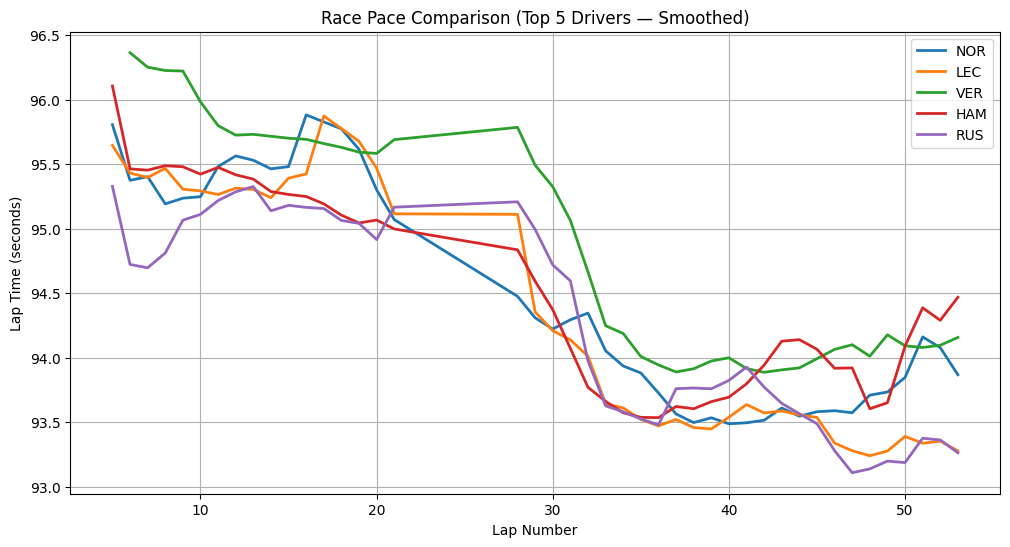

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for drv in filtered['Driver'].unique():
    drv_data = filtered[filtered['Driver'] == drv].copy()

    # sort laps
    drv_data = drv_data.sort_values('LapNumber')

    # smoothing
    drv_data['Smooth'] = drv_data['LapTime_sec'].rolling(5).mean()

    plt.plot(drv_data['LapNumber'],
             drv_data['Smooth'],
             label=drv,
             linewidth=2)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Race Pace Comparison (Top 5 Drivers — Smoothed)')
plt.legend()
plt.grid(True)

plt.show()

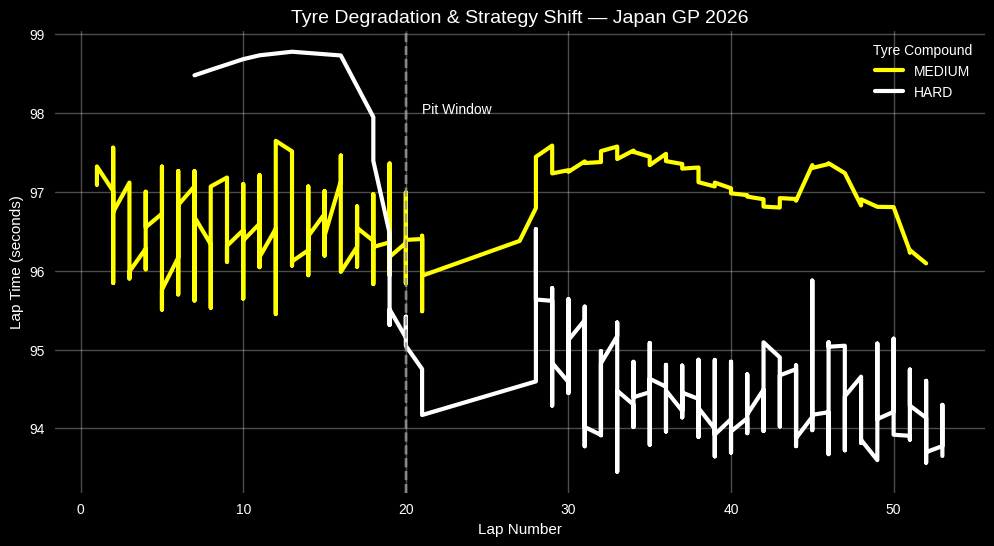

In [28]:
plt.figure(figsize=(12,6))
plt.style.use('dark_background')

color_map = {
    'SOFT': 'red',
    'MEDIUM': 'yellow',
    'HARD': 'white'
}

for compound in laps['Compound'].unique():
    comp_data = laps[laps['Compound'] == compound].copy()

    comp_data = comp_data.sort_values('LapNumber')
    comp_data['Smooth'] = comp_data['LapTime_sec'].rolling(5).mean()

    plt.plot(comp_data['LapNumber'],
             comp_data['Smooth'],
             label=compound,
             color=color_map.get(compound, 'gray'),
             linewidth=3)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Tyre Performance Comparison (F1 Style)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=20, linestyle='--', alpha=0.5)
plt.axvline(x=20, linestyle='--', color='gray', alpha=0.7)
plt.text(21, 98, 'Pit Window', color='white')
plt.title('Tyre Degradation & Strategy Shift — Japan GP 2026', fontsize=14)
plt.legend(title="Tyre Compound")
plt.show()


In [31]:
# ---------------------------
# Stint Analysis
# ---------------------------


stints = session.laps.groupby(['Driver','Stint','Compound'])['LapNumber'].count().reset_index()
stints.columns = ['Driver','Stint','Compound','StintLength']

stints

,Driver,Stint,Compound,StintLength
0,ALB,1.0,MEDIUM,22
1,ALB,2.0,HARD,23
2,ALB,3.0,SOFT,1
3,ALB,4.0,SOFT,1
4,ALB,5.0,SOFT,1
5,ALB,6.0,SOFT,1
6,ALB,7.0,MEDIUM,2
7,ALO,1.0,MEDIUM,21
8,ALO,2.0,HARD,2
9,ALO,3.0,MEDIUM,29


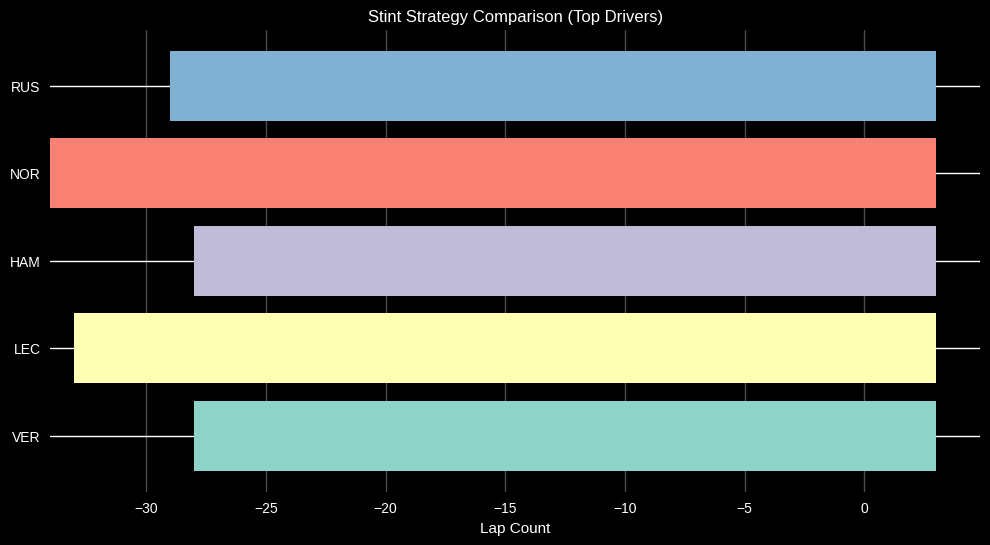

In [33]:
# select top drivers (same jo use kiye the)
drivers = ['VER', 'LEC', 'HAM', 'NOR', 'RUS']

stint_filtered = stints[stints['Driver'].isin(drivers)]

plt.figure(figsize=(12,6))

for drv in drivers:
    drv_data = stint_filtered[stint_filtered['Driver'] == drv]

    plt.barh(drv_data['Driver'],
             drv_data['StintLength'],
             left=drv_data['Stint'].cumsum() - drv_data['StintLength'],
             label=drv)

plt.xlabel('Lap Count')
plt.title('Stint Strategy Comparison (Top Drivers)')
plt.grid(axis='x', alpha=0.3)
color_map = {'SOFT':'red','MEDIUM':'yellow','HARD':'white'}
plt.show()

In [35]:
# calculate gap to leader
laps_sorted = laps.sort_values(['LapNumber','Position'])

leader_laps = laps_sorted[laps_sorted['Position'] == 1][['LapNumber','LapTime_sec']]
leader_laps = leader_laps.rename(columns={'LapTime_sec':'LeaderTime'})

merged = pd.merge(laps_sorted, leader_laps, on='LapNumber')

merged['GapToLeader'] = merged['LapTime_sec'] - merged['LeaderTime']

In [37]:
consistency = laps.groupby('Driver')['LapTime_sec'].std().reset_index()
consistency = consistency.sort_values('LapTime_sec')

consistency.head(10)

,Driver,LapTime_sec
20,STR,0.390573
1,ALO,0.714201
3,BEA,0.753226
5,BOT,0.832316
6,COL,0.880573
7,GAS,0.912425
16,PER,0.931555
17,PIA,0.934168
4,BOR,0.940958
21,VER,0.990434


In [38]:
pit = session.laps[session.laps['PitInTime'].notnull()]

pit[['Driver','LapNumber','LapTime']]

,Driver,LapNumber,LapTime
15,NOR,16.0,0 days 00:01:38.222000
74,GAS,22.0,0 days 00:02:00.960000
126,PER,21.0,0 days 00:01:48.146000
180,ANT,22.0,0 days 00:01:53.376000
232,ALO,21.0,0 days 00:01:59.021000
234,ALO,23.0,0 days 00:01:53.088000
280,LEC,17.0,0 days 00:01:37.448000
337,STR,21.0,0 days 00:01:51.658000
340,STR,24.0,0 days 00:01:47.875000
346,STR,30.0,0 days 00:01:40.631000


In [39]:
# sort laps properly
laps_sorted = laps.sort_values(['LapNumber','Position'])

# get leader lap time per lap
leader = laps_sorted[laps_sorted['Position'] == 1][['LapNumber','LapTime_sec']]
leader = leader.rename(columns={'LapTime_sec':'LeaderTime'})

# merge with full data
merged = laps_sorted.merge(leader, on='LapNumber')

# calculate gap
merged['GapToLeader'] = merged['LapTime_sec'] - merged['LeaderTime']

merged.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTime_sec,LeaderTime,GapToLeader
0,0 days 01:05:20.232000,PIA,81,0 days 00:01:35.268000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.939000,...,2026-03-29 05:14:02.079,1,1.0,False,,False,False,95.268,95.268,0.000
1,0 days 01:05:21.324000,LEC,16,0 days 00:01:36.360000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.648000,...,2026-03-29 05:14:02.079,1,2.0,False,,False,False,96.360,95.268,1.092
2,0 days 01:05:22.170000,NOR,1,0 days 00:01:37.206000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.011000,...,2026-03-29 05:14:02.079,1,3.0,False,,False,False,97.206,95.268,1.938
3,0 days 01:05:22.787000,RUS,63,0 days 00:01:37.823000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.185000,...,2026-03-29 05:14:02.079,1,4.0,False,,False,False,97.823,95.268,2.555
4,0 days 01:05:23.350000,HAM,44,0 days 00:01:38.386000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.171000,...,2026-03-29 05:14:02.079,1,5.0,False,,False,False,98.386,95.268,3.118


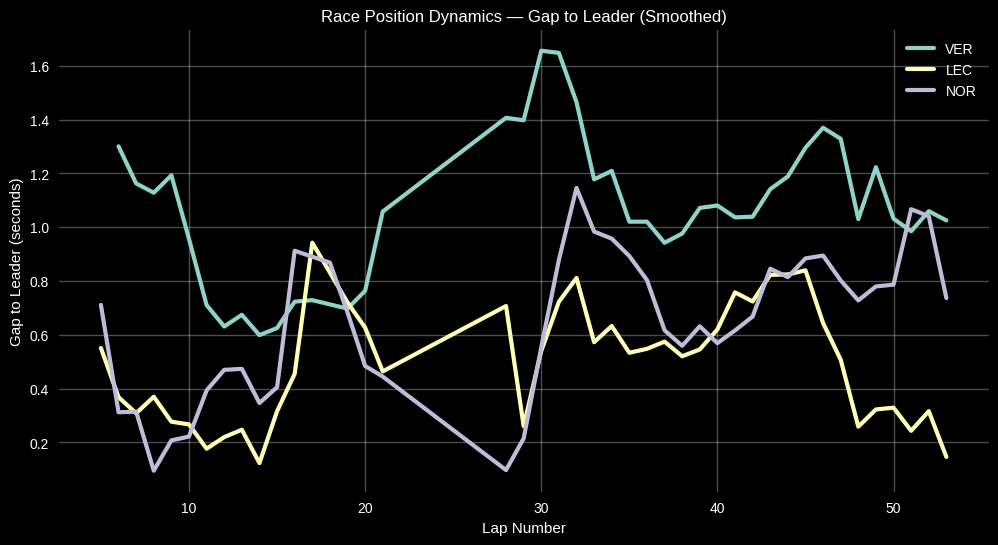

In [40]:
plt.figure(figsize=(12,6))
plt.style.use('dark_background')

drivers = ['VER','LEC','NOR']

for drv in drivers:
    d = merged[merged['Driver'] == drv].copy()
    d = d.sort_values('LapNumber')

    # smoothing
    d['SmoothGap'] = d['GapToLeader'].rolling(5).mean()

    plt.plot(d['LapNumber'],
             d['SmoothGap'],
             label=drv,
             linewidth=3)

plt.xlabel('Lap Number')
plt.ylabel('Gap to Leader (seconds)')
plt.title('Race Position Dynamics — Gap to Leader (Smoothed)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [41]:
# pick drivers
drivers = ['VER', 'LEC']

# get their pit laps
pit_laps = session.laps[
    (session.laps['PitInTime'].notnull()) &
    (session.laps['Driver'].isin(drivers))
]

pit_laps[['Driver','LapNumber']]

,Driver,LapNumber
280,LEC,17.0
472,VER,22.0


In [42]:
# define pit laps
lec_pit = 17
ver_pit = 22

# get data around pit window (±2 laps)
lec_window = laps[(laps['Driver']=='LEC') & (laps['LapNumber'].between(lec_pit-2, lec_pit+2))]
ver_window = laps[(laps['Driver']=='VER') & (laps['LapNumber'].between(ver_pit-2, ver_pit+2))]

lec_window[['LapNumber','LapTime_sec']]

,LapNumber,LapTime_sec
278,15.0,95.903
279,16.0,95.307
280,17.0,97.448
282,19.0,94.426


In [43]:
ver_window[['LapNumber','LapTime_sec']]

,LapNumber,LapTime_sec
470,20.0,95.600
471,21.0,96.124
